# 03 · XGBoost 上手

sklearn 的 `GradientBoosting` 概念清楚，但慢。工業界與 Kaggle 競賽真正在用的是 **XGBoost**——更快、內建正則化、會自己處理缺值。這堂課讓你跑出第一個 XGBoost 模型。

## 學習目標

- 用 `XGBClassifier`（sklearn 風格 API）訓練模型
- 知道 XGBoost 相較 sklearn GBDT 的三個賣點
- 認識最常調的三個參數：`n_estimators` / `learning_rate` / `max_depth`

## 1. 第一個 XGBoost

XGBoost 提供與 sklearn 一模一樣的 `fit` / `predict` 介面——你已經會了。

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=3,
    eval_metric="logloss", random_state=42,
)
model.fit(X_train, y_train)
print(f"XGBoost 測試準確率：{model.score(X_test, y_test):.3f}")

XGBoost 測試準確率：0.965


## 2. XGBoost 比 sklearn GBDT 強在哪？

- **速度**：用了二階梯度資訊與工程最佳化，大資料快非常多。
- **正則化**：內建 L1/L2（`reg_alpha` / `reg_lambda`）抑制過擬合——sklearn GBDT 沒有。
- **缺值處理**：自動學習缺值該往左還是往右走，不用你補值。

## 3. 三個最常調的參數

| 參數 | 控制 | 直覺 |
| --- | --- | --- |
| `n_estimators` | 樹的數量 | 越多越強，但會過擬合 |
| `learning_rate` | 每棵樹的步幅 | 越小越穩，但要配更多樹 |
| `max_depth` | 每棵樹多深 | 越深越能抓交互作用，也越容易過擬合 |

`learning_rate` 與 `n_estimators` 是一對：學習率減半，樹大約要加倍。下一課專門處理「樹該種幾棵」這個過擬合問題。

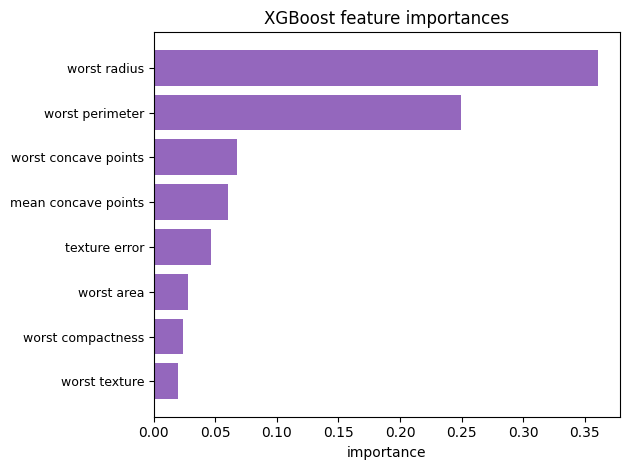

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 看 XGBoost 認為哪些特徵重要
data = load_breast_cancer()
imp = model.feature_importances_
order = np.argsort(imp)[::-1][:8]
plt.barh(range(len(order)), imp[order][::-1], color="tab:purple")
plt.yticks(range(len(order)), np.array(data.feature_names)[order][::-1], fontsize=9)
plt.xlabel("importance"); plt.title("XGBoost feature importances")
plt.tight_layout(); plt.show()

## 小結

- `XGBClassifier` / `XGBRegressor` 用的是你熟悉的 sklearn 介面。
- XGBoost 三大賣點：**快、內建正則化、自動處理缺值**。
- 最常調：`n_estimators`、`learning_rate`、`max_depth`。

## 練習

1. 把 `max_depth` 從 3 改成 8，訓練準確率與測試準確率分別怎麼變？
2. 改用 `XGBRegressor` 在 `load_diabetes` 上做迴歸，看 R²。

下一課，學會用 **early stopping** 自動決定樹該種幾棵。